In [13]:
import numpy as np
from scipy.stats import qmc
from scipy.special import comb
import matplotlib.pyplot as plt
import pandas as pd
import os

# ============================================================
# Physical Constants
# ============================================================
D = 38.0           # diameter (mm)
R = D / 2           # radius = 19 mm
L_CYL = 220.0       # cylinder length (mm)
L_HALF = L_CYL / 2  # half-length = 110 mm

def ellipse_axes(R, e):
    if e <= 0: return R, R
    k = np.sqrt(1 - e**2)
    denom = 3*(1+k) - np.sqrt((3+k)*(1+3*k))
    a = 2*R / denom
    b = a * k
    return a, b

_, b_min = ellipse_axes(R, 0.7)
print(f'D={D}mm, L={L_CYL}mm, R={R}mm')
print(f'b(e=0.7) = {b_min:.2f}mm')

# ============================================================
# DV Bounds (7 variables)
# ============================================================
# Bezier 6CP deg5, C2 enforced at both symmetry axes
# Reparametrized: x3 = 2*x1 + Dx, xP3 = x2 + fP3*Dx
#   C2 constraints: x2 = 2*x1, yP3 = 2*y3
# ============================================================

bounds = np.array([
    [ 2.0,  12.0],   # y1   — start height
    [25.0,  35.0],   # x1   — horizontal section length
    [ 5.0,  26.0],   # Dx   — transition zone (x3 = 2*x1 + Dx)
    [ 1.0,   6.5],   # y3   — end height (yP3 = 2*y3)
    [ 0.5,  13.0],   # yP2  — P2 height (free)
    [ 0.0,   3.0],   # fP3  — P3 x-ratio (xP3 = x2 + fP3*Dx)
    [ 0.0,   0.7],   # ecc  — eccentricity
])

dv_names = ['y1', 'x1', 'Dx', 'y3', 'yP2', 'fP3', 'ecc']

print('\n[DV Bounds]')
for name, (lo, hi) in zip(dv_names, bounds):
    print(f'  {name:>4s} ∈ [{lo:>5.1f}, {hi:>5.1f}]')

x3_range = (2*bounds[1,0]+bounds[2,0], 2*bounds[1,1]+bounds[2,1])
print(f'\n[Implied] x3 = 2*x1+Dx ∈ [{x3_range[0]:.0f}, {x3_range[1]:.0f}]')
print(f'[Implied] x2 = 2*x1     ∈ [{2*bounds[1,0]:.0f}, {2*bounds[1,1]:.0f}]')
print(f'[Implied] yP3 = 2*y3    ∈ [{2*bounds[3,0]:.0f}, {2*bounds[3,1]:.0f}]')


D=38.0mm, L=220.0mm, R=19.0mm
b(e=0.7) = 15.72mm

[DV Bounds]
    y1 ∈ [  2.0,  12.0]
    x1 ∈ [ 25.0,  35.0]
    Dx ∈ [  5.0,  26.0]
    y3 ∈ [  1.0,   6.5]
   yP2 ∈ [  0.5,  13.0]
   fP3 ∈ [  0.0,   3.0]
   ecc ∈ [  0.0,   0.7]

[Implied] x3 = 2*x1+Dx ∈ [55, 96]
[Implied] x2 = 2*x1     ∈ [50, 70]
[Implied] yP3 = 2*y3    ∈ [2, 13]


Running 5000 LHS trials (n=40, d=7)...

Best CD = 2.215245e-02  (MC baseline = 7.844806e-02, 72% better)


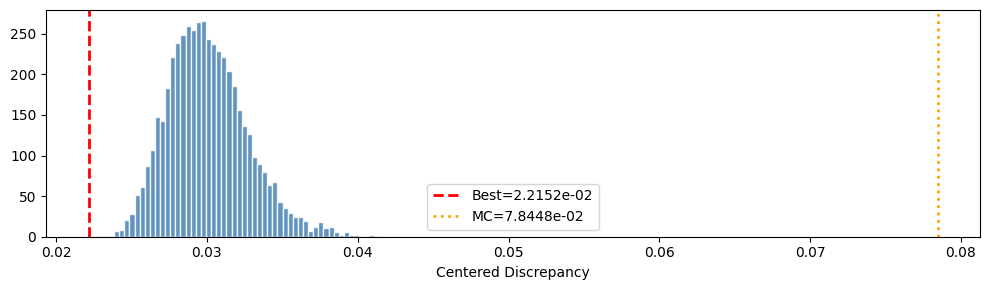

In [14]:
# ============================================================
# LHS Sampling — best discrepancy selection
# ============================================================

num_samples = 40
n_trials = 5000
num_vars = len(bounds)

best_disc = np.inf
best_samples = None
all_discs = []

print(f'Running {n_trials} LHS trials (n={num_samples}, d={num_vars})...')

for trial in range(n_trials):
    sampler = qmc.LatinHypercube(d=num_vars)
    pts = sampler.random(n=num_samples)
    disc = qmc.discrepancy(pts, method='CD')
    all_discs.append(disc)
    if disc < best_disc:
        best_disc = disc
        best_samples = pts

all_discs = np.array(all_discs)
sample_points = best_samples
scaled_samples = qmc.scale(sample_points, bounds[:, 0], bounds[:, 1])

# Quality report
mc_discs = [qmc.discrepancy(np.random.rand(num_samples, num_vars), method='CD') for _ in range(200)]
mc_baseline = np.mean(mc_discs)
improvement = (1 - best_disc / mc_baseline) * 100

print(f'\nBest CD = {best_disc:.6e}  (MC baseline = {mc_baseline:.6e}, {improvement:.0f}% better)')

fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(all_discs, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(best_disc, color='red', lw=2, ls='--', label=f'Best={best_disc:.4e}')
ax.axvline(mc_baseline, color='orange', lw=2, ls=':', label=f'MC={mc_baseline:.4e}')
ax.set_xlabel('Centered Discrepancy'); ax.legend()
plt.tight_layout(); plt.show()


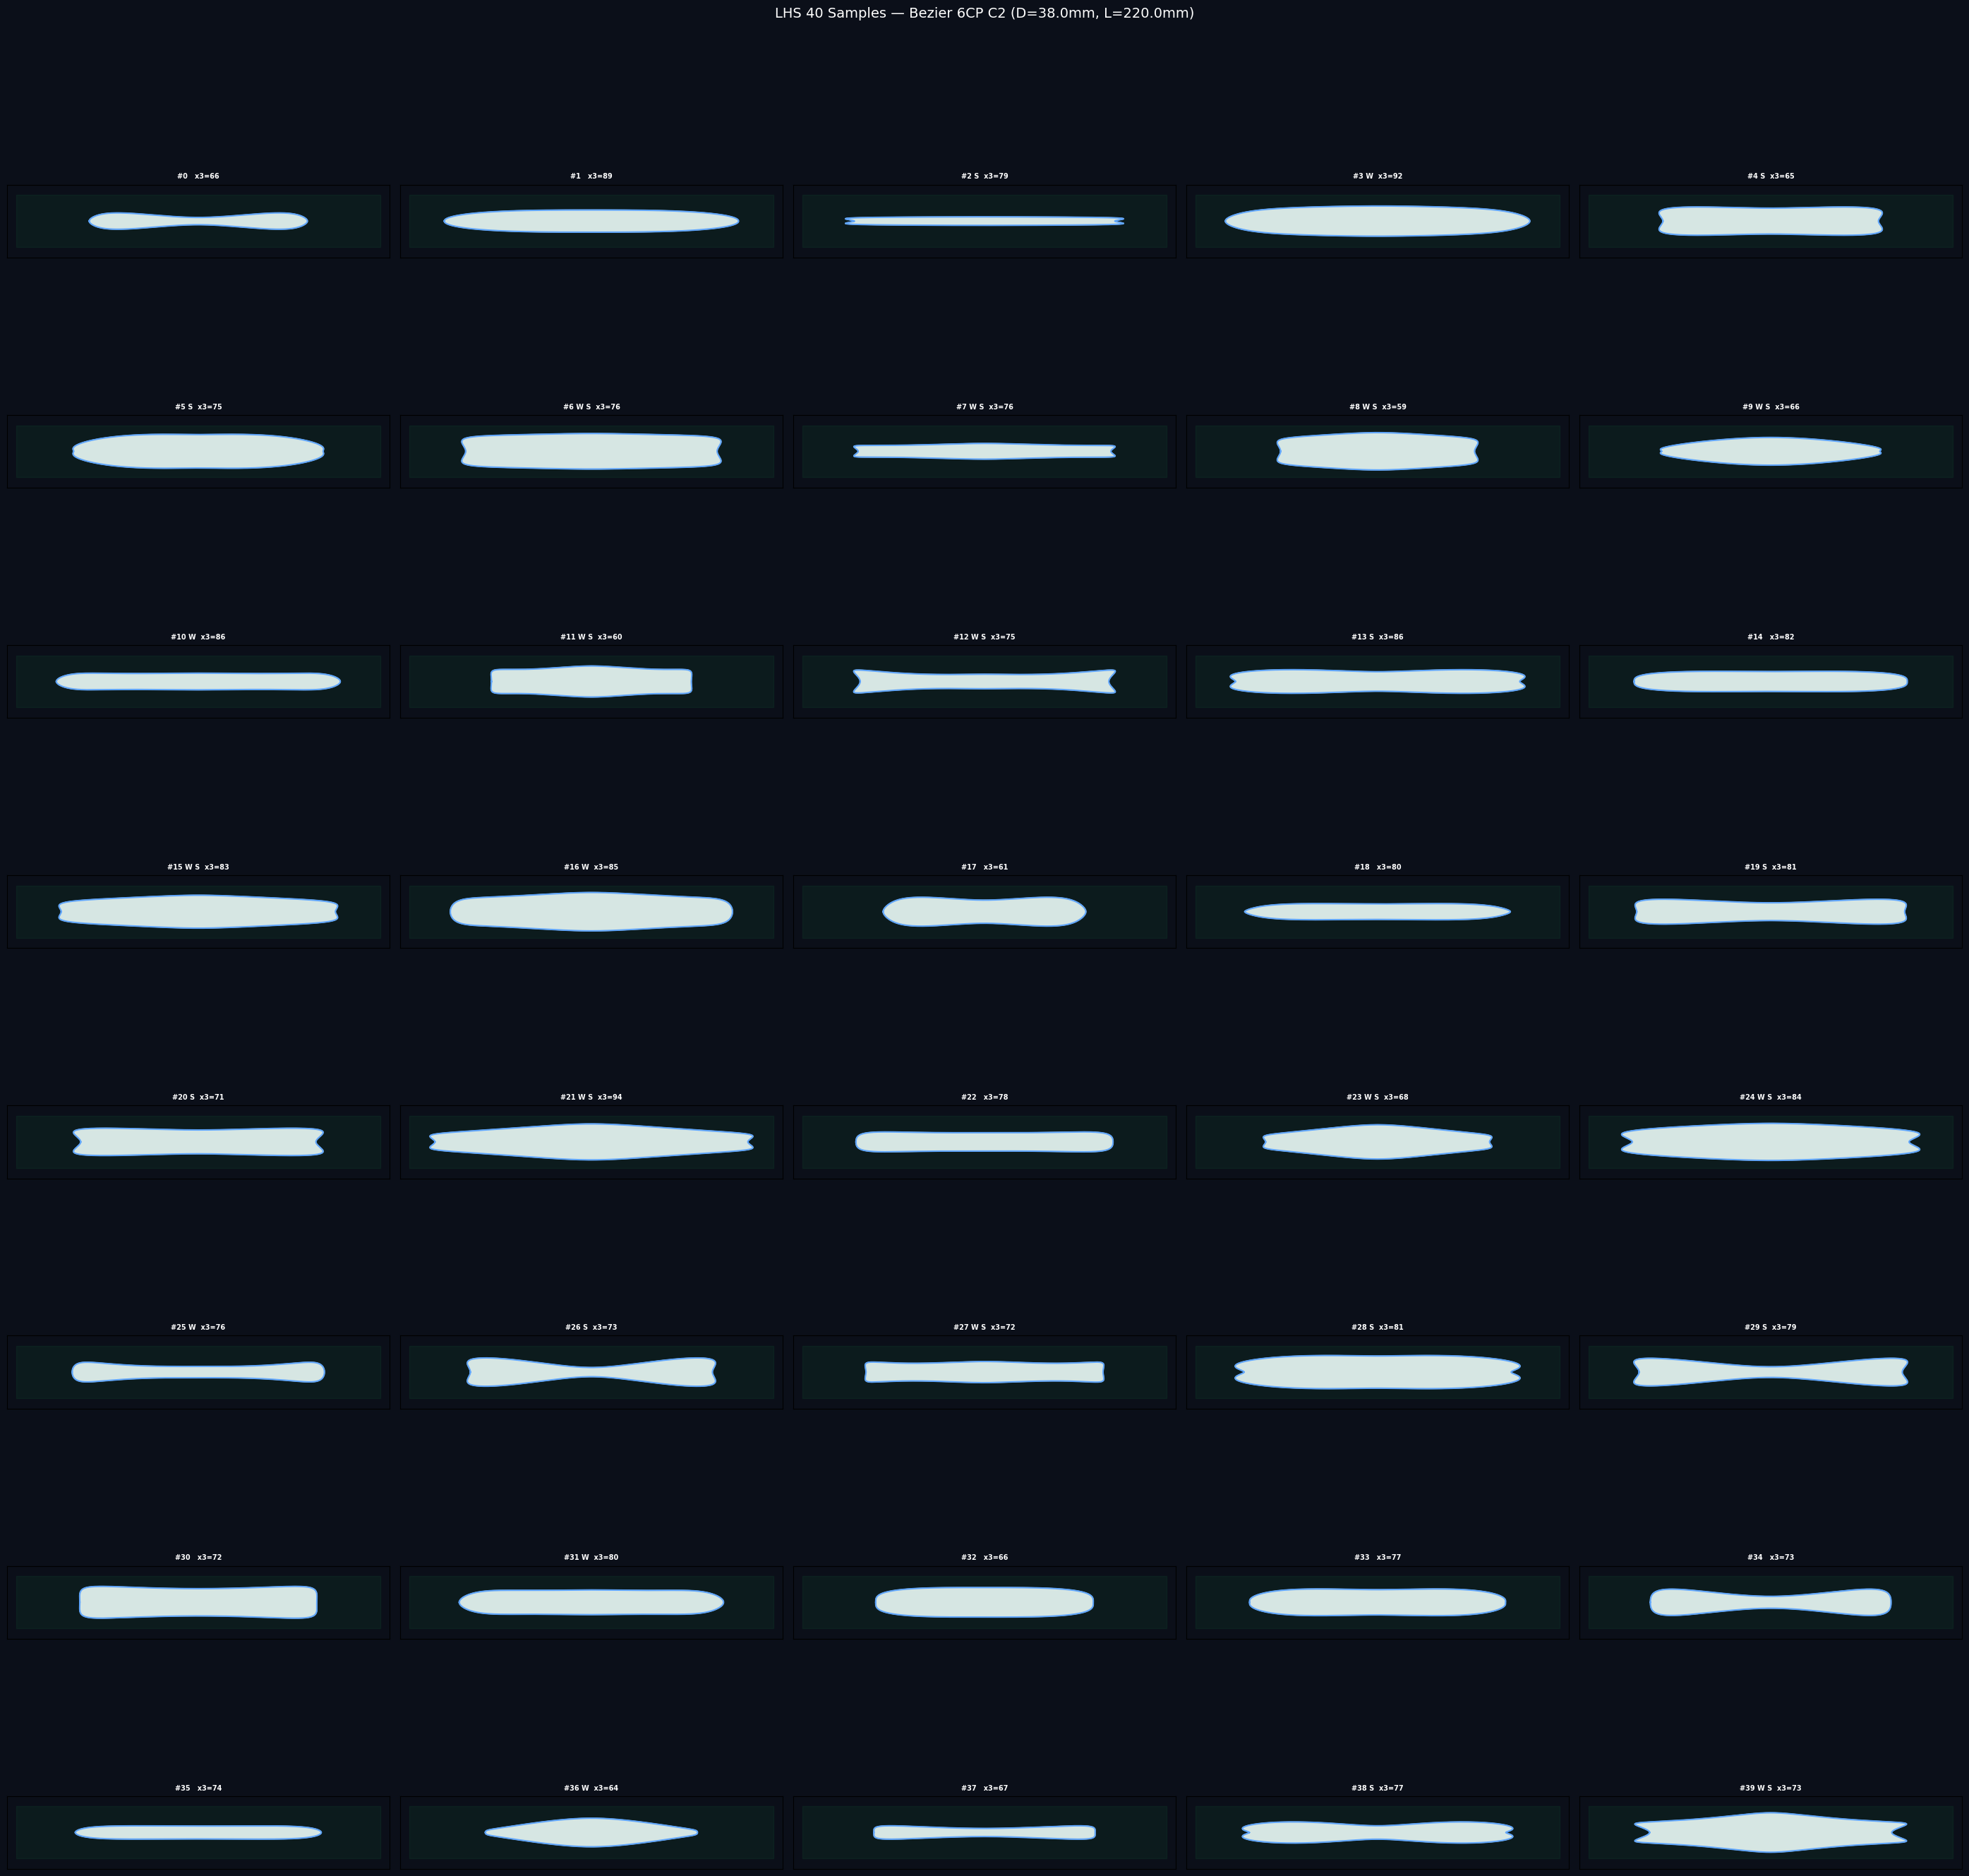

In [15]:
# ============================================================
# Bezier 6CP deg5 — C2 enforced curve generation
# ============================================================

def bernstein(i, n, t):
    return comb(n, i, exact=True) * (t**i) * ((1-t)**(n-i))

def generate_bezier_Q1(dv, num_points=100):
    """
    Generate quarter cutout curve (Q1: x>=0, y>=0).
    
    Parameters
    ----------
    dv : array-like, shape (7,)
        [y1, x1, Dx, y3, yP2, fP3, ecc]
    
    Returns
    -------
    curve_points : ndarray (num_points, 2)
    control_points : ndarray (6, 2)
    derived : dict with x2, x3, xP3, yP3 values
    """
    y1, x1, Dx, y3, yP2, fP3, _ecc = dv
    
    # Derived (C2 enforced)
    x2  = 2 * x1
    x3  = x2 + Dx
    xP3 = x2 + fP3 * Dx
    yP3 = 2 * y3
    
    # 6 Control Points (degree 5)
    cps = np.array([
        [0.0, y1 ],   # P0: on y-axis (C1+C2 start)
        [x1,  y1 ],   # P1: horizontal tangent (C1)
        [x2,  yP2],   # P2: x=2*x1 (C2), y free
        [xP3, yP3],   # P3: x free, y=2*y3 (C2)
        [x3,  y3 ],   # P4: vertical tangent pair (C1)
        [x3,  0.0],   # P5: on x-axis (C1+C2 end)
    ])
    
    deg = 5
    t = np.linspace(0, 1, num_points)
    pts = np.zeros((num_points, 2))
    for i in range(6):
        B = bernstein(i, deg, t)
        pts[:, 0] += cps[i, 0] * B
        pts[:, 1] += cps[i, 1] * B
    
    derived = {'x2': x2, 'x3': x3, 'xP3': xP3, 'yP3': yP3}
    return pts, cps, derived


def mirror_to_full(q1):
    """Q1 curve → full closed cutout (4-fold symmetry)"""
    tr = q1                                     # top-right (original)
    tl = q1[::-1].copy(); tl[:, 0] *= -1        # top-left
    bl = q1.copy(); bl[:, 0] *= -1; bl[:, 1] *= -1  # bottom-left
    br = q1[::-1].copy(); br[:, 1] *= -1        # bottom-right
    return np.vstack([tl, tr, br[1:], bl[1:], tl[0:1]])  # closed loop


# ============================================================
# Visualize all samples — full cutout
# ============================================================

n_cols = 5
n_rows = int(np.ceil(num_samples / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(28, n_rows * 3.5))
axes = axes.flatten()

for i in range(num_samples):
    ax = axes[i]
    dv = scaled_samples[i]
    q1, cps_i, drv = generate_bezier_Q1(dv)
    full = mirror_to_full(q1)
    
    is_waist = dv[4] < dv[0] * 0.85   # yP2 < y1
    is_scoop = q1[:, 0].max() > drv['x3'] + 0.1
    
    ax.fill(full[:, 0], full[:, 1], color='white', alpha=0.95)
    ax.fill(full[:, 0], full[:, 1], color='tab:blue', alpha=0.06)
    ax.plot(full[:, 0], full[:, 1], color='#60a5fa', lw=1.5)
    
    # Tape spring boundary
    ax.fill_between([-L_HALF, L_HALF], -b_min, b_min,
                     color='#22c55e', alpha=0.07)
    
    tags = []
    if is_waist: tags.append('W')
    if is_scoop: tags.append('S')
    
    ax.set_aspect('equal')
    ax.set_xlim(-L_HALF * 1.05, L_HALF * 1.05)
    ax.set_ylim(-b_min * 1.4, b_min * 1.4)
    ax.set_facecolor('#0b0f19')
    ax.set_title(f'#{i} {" ".join(tags)}  x3={drv["x3"]:.0f}',
                 fontsize=7, color='white', fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

# Hide unused axes
for j in range(num_samples, len(axes)):
    axes[j].set_visible(False)

fig.patch.set_facecolor('#0b0f19')
fig.suptitle(f'LHS {num_samples} Samples — Bezier 6CP C2 (D={D}mm, L={L_CYL}mm)',
             fontsize=14, y=1.01, color='white')
plt.tight_layout()
plt.show()


In [16]:
# ============================================================
# CSV Export — cutout coordinates + design variables
# ============================================================

output_dir = 'specimen'   # 저장 폴더
os.makedirs(output_dir, exist_ok=True)

for i in range(num_samples):
    dv = scaled_samples[i]
    y1, x1, Dx, y3, yP2, fP3, ecc_val = dv
    
    # Derived
    x2  = 2 * x1
    x3  = x2 + Dx
    xP3 = x2 + fP3 * Dx
    yP3 = 2 * y3
    
    # Generate full cutout
    q1, _, _ = generate_bezier_Q1(dv, num_points=100)
    full = mirror_to_full(q1)
    
    # DataFrame
    df = pd.DataFrame(full, columns=['X', 'Y'])
    
    # DV columns — first row only
    n_rows = len(df)
    nan_tail = [np.nan] * (n_rows - 1)
    
    df['Eccentricity'] = [ecc_val]  + nan_tail
    df['y1']           = [y1]       + nan_tail
    df['x1']           = [x1]       + nan_tail
    df['Dx']           = [Dx]       + nan_tail
    df['y3']           = [y3]       + nan_tail
    df['yP2']          = [yP2]      + nan_tail
    df['fP3']          = [fP3]      + nan_tail
    # Derived values (for reference)
    df['x2_derived']   = [x2]       + nan_tail
    df['x3_derived']   = [x3]       + nan_tail
    df['xP3_derived']  = [xP3]      + nan_tail
    df['yP3_derived']  = [yP3]      + nan_tail
    
    filepath = os.path.join(output_dir, f'cutout_points_{i}.csv')
    df.to_csv(filepath, index=False)

print(f'{num_samples}개 CSV 저장 완료 → ./{output_dir}/')
print(f'\nSample CSV (#{0}):')
print(pd.read_csv(os.path.join(output_dir, 'cutout_points_0.csv')).head(3).to_string())


40개 CSV 저장 완료 → ./specimen/

Sample CSV (#0):
           X         Y  Eccentricity        y1        x1         Dx        y3       yP2      fP3  x2_derived  x3_derived  xP3_derived  yP3_derived
0 -65.900783  0.000000       0.42882  2.197025  27.26339  11.374002  2.411296  8.220361  0.38198   54.526781   65.900783    58.871422     4.822592
1 -65.893709  0.121792           NaN       NaN       NaN        NaN       NaN       NaN      NaN         NaN         NaN          NaN          NaN
2 -65.872866  0.243637           NaN       NaN       NaN        NaN       NaN       NaN      NaN         NaN         NaN          NaN          NaN
